In [1]:
import numpy as np
import os
import pandas as pd 
import matplotlib.pyplot as plt 
from astropy.io import fits

#### Retrieving and sorting the LAMOST data files

In [2]:
folder_directory = "/home/arbiter/projects/data_downloads"

folder_list = os.listdir(folder_directory)
folder_list = [x for x in folder_list if x != "Lamost_metadata"]

folder_list

['LAMOST_new_chunk_19',
 'LAMOST_new_chunk_7',
 'LAMOST_new_chunk_20',
 'LAMOST_new_chunk_13',
 'LAMOST_new_chunk_11',
 'LAMOST_new_chunk_4',
 'LAMOST_new_chunk_8',
 'LAMOST_new_chunk_15',
 'LAMOST_new_chunk_5',
 'LAMOST_new_chunk_2',
 'LAMOST_new_chunk_16',
 'LAMOST_new_chunk_14',
 'LAMOST_new_chunk_1',
 'LAMOST_new_chunk_9',
 'LAMOST_new_chunk_17',
 'LAMOST_new_chunk_12',
 'LAMOST_new_chunk_3',
 'LAMOST_new_chunk_10',
 'LAMOST_new_chunk_6',
 'LAMOST_new_chunk_18']

In [3]:
folder_list.sort(key=lambda x: int(x.split("_")[-1]))
folder_list

['LAMOST_new_chunk_1',
 'LAMOST_new_chunk_2',
 'LAMOST_new_chunk_3',
 'LAMOST_new_chunk_4',
 'LAMOST_new_chunk_5',
 'LAMOST_new_chunk_6',
 'LAMOST_new_chunk_7',
 'LAMOST_new_chunk_8',
 'LAMOST_new_chunk_9',
 'LAMOST_new_chunk_10',
 'LAMOST_new_chunk_11',
 'LAMOST_new_chunk_12',
 'LAMOST_new_chunk_13',
 'LAMOST_new_chunk_14',
 'LAMOST_new_chunk_15',
 'LAMOST_new_chunk_16',
 'LAMOST_new_chunk_17',
 'LAMOST_new_chunk_18',
 'LAMOST_new_chunk_19',
 'LAMOST_new_chunk_20']

In [4]:
directory_list = []

for folder in folder_list:
    for root, dirs, files in os.walk(f"{folder_directory}/{folder}"):
        root = root.split("/")
        if len(root) == 8:
            directory_list.append("/".join(root))

len(directory_list)

35

In [5]:
directory_list

['/home/arbiter/projects/data_downloads/LAMOST_new_chunk_1/20111024/F5902',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_2/20111024/F5902',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_2/20111024/F5909',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_2/20111024/F5907',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_2/20111024/M5901',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_3/20111024/M5904',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_3/20111024/M5901',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_3/20111025/B6001',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_4/20111025/B6001',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_5/20111027/B6202',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_5/20111025/B6001',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_6/20111027/B6202',
 '/home/arbiter/projects/data_downloads/LAMOST_new_chunk_7/20111027/B6202',
 '/home/arbi

#### Extracting stellar metadata

In [6]:
metadata_lamost_dir = f"{folder_directory}/Lamost_metadata"
metadata_file_list = os.listdir(metadata_lamost_dir)

metadata_file_list.sort(key=lambda x: int(x.split("_")[1]))

metadataframe_list = []
for file in metadata_file_list:
    if "Zone" not in file:
        dataframe = pd.read_csv(f"{metadata_lamost_dir}/{file}")

        metadataframe_list.append(dataframe)

meta_df = pd.concat(metadataframe_list, axis = 0)


In [7]:
meta_df.shape

(20000, 17)

In [8]:
meta_df.to_csv("lamost_meta.csv")

In [10]:
meta_df["obsid"].nunique()

20000

In [8]:
meta_df.head()

,obsid,uid,obsdate,lmjd,mjd,planid,spid,fiberid,class,subclass,z,ra,dec,rv,logg,teff,feh
0,101001,G12763466510210,2011-10-24,55859,55858,F5902,1,1,STAR,G7,-0.000139,332.202274,-2.056767,-41.58,4.545,5178.32,-0.497
1,101005,G12763553667654,2011-10-24,55859,55858,F5902,1,5,STAR,G0,-0.000251,332.535456,-2.116436,-75.14,3.722,5314.64,-0.737
2,101008,G12763564851128,2011-10-24,55859,55858,F5902,1,8,STAR,F9,0.000087,332.368745,-1.955771,26.20,4.594,5580.10,-0.019
3,101009,G12763486062568,2011-10-24,55859,55858,F5902,1,9,STAR,G0,-0.000115,332.206665,-1.868653,-34.54,4.090,5555.26,-0.470
4,101016,G12763535296239,2011-10-24,55859,55858,F5902,1,16,STAR,K3,-0.000044,332.348725,-2.136096,-13.11,4.691,4588.43,-0.228


In [82]:
meta_df.describe()

,obsid,lmjd,mjd,spid,fiberid,z,ra,dec,rv,logg,teff,feh
count,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9.628372e+05,55861.857550,55860.857550,8.391600,125.578950,-0.000085,213.428971,27.353975,-25.620264,4.142766,5555.739368,-0.249140
std,4.065472e+05,1.409027,1.409027,4.738594,71.506301,0.000164,139.366289,9.157434,49.158185,0.599391,914.003823,0.338287
min,1.010010e+05,55859.000000,55858.000000,1.000000,1.000000,-0.001666,0.007383,-3.162670,-499.310000,-0.054000,3822.520000,-2.470000
25%,7.022478e+05,55862.000000,55861.000000,5.000000,64.000000,-0.000155,61.689315,27.786703,-46.482500,4.020000,4941.500000,-0.430000
50%,9.131875e+05,55862.000000,55861.000000,8.000000,125.000000,-0.000074,330.902355,29.463755,-22.255000,4.264000,5521.455000,-0.222000
75%,1.311022e+06,55863.000000,55862.000000,13.000000,187.000000,0.000007,342.223047,30.898202,1.950000,4.541000,5995.665000,-0.028000
max,1.603026e+06,55863.000000,55862.000000,16.000000,250.000000,0.000936,359.996945,43.038710,280.640000,4.900000,12646.200000,0.901000


In [83]:
meta_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   obsid     20000 non-null  int64  
 1   uid       20000 non-null  object 
 2   obsdate   20000 non-null  object 
 3   lmjd      20000 non-null  int64  
 4   mjd       20000 non-null  int64  
 5   planid    20000 non-null  object 
 6   spid      20000 non-null  int64  
 7   fiberid   20000 non-null  int64  
 8   class     20000 non-null  object 
 9   subclass  20000 non-null  object 
 10  z         20000 non-null  float64
 11  ra        20000 non-null  float64
 12  dec       20000 non-null  float64
 13  rv        20000 non-null  float64
 14  logg      20000 non-null  float64
 15  teff      20000 non-null  float64
 16  feh       20000 non-null  float64
dtypes: float64(7), int64(5), object(5)
memory usage: 2.7+ MB


#### Accessing a FITS format: 

In [96]:
with fits.open(f"{directory_list[0]}/spec-55859-F5902_sp10-085.fits.gz") as star:
    star.info()

    primary_hdu = star[0]
    primary_header = primary_hdu.header
    secondary_hdu = star[1]
    secondary_header = secondary_hdu.header
    secondary_data = secondary_hdu.data

primary_header

Filename: /home/arbiter/projects/data_downloads/LAMOST_new_chunk_1/20111024/F5902/spec-55859-F5902_sp10-085.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3909E, 3909E, 3909E, 3909E, 3909E, 3909E]   


SIMPLE  =                    T /Primary Header created by MWRFITS v1.11b        
BITPIX  =                   16 /                                                
NAXIS   =                    0 / Number of array dimensions                     
NAXIS1  =                 3909 /                                                
NAXIS2  =                    5 /                                                
EXTEND  =                    T /                                                
                                                                                
COMMENT --------FILE INFORMATION                                                
FILENAME= 'spec-55859-F5902_sp10-085.fits' /                                    
OBSID   =               110085 / Unique number ID of this spectrum              
AUTHOR  = 'LAMOST Pipeline'    / Who compiled the information                   
DATA_V  = 'LAMOST DR11'        / Data release version                           
N_EXTEN =                   

In [97]:
with fits.open(f"{directory_list[0]}/spec-55859-F5902_sp10-085.fits.gz") as star:
    star.info()

    primary_hdu = star[0]
    primary_header = primary_hdu.header
    secondary_hdu = star[1]
    secondary_header = secondary_hdu.header
    secondary_data = secondary_hdu.data

secondary_header

Filename: /home/arbiter/projects/data_downloads/LAMOST_new_chunk_1/20111024/F5902/spec-55859-F5902_sp10-085.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3909E, 3909E, 3909E, 3909E, 3909E, 3909E]   


XTENSION= 'BINTABLE'           /Binary table written by MWRFITS v1.11b          
BITPIX  =                    8 /Required value                                  
NAXIS   =                    2 /Required value                                  
NAXIS1  =                93816 /Number of bytes per row                         
NAXIS2  =                    1 /Number of rows                                  
PCOUNT  =                    0 /Normally 0 (no varying arrays)                  
GCOUNT  =                    1 /Required value                                  
TFIELDS =                    6 /Number of columns in table                      
COMMENT                                                                         
COMMENT  *** End of mandatory fields ***                                        
COMMENT                                                                         
EXTNAME = 'COADD   '           / The extension name                             
COMMENT                     

In [98]:
with fits.open(f"{directory_list[0]}/spec-55859-F5902_sp10-085.fits.gz") as star:
    star.info()

    primary_hdu = star[0]
    primary_header = primary_hdu.header
    secondary_hdu = star[1]
    secondary_header = secondary_hdu.header
    secondary_data = secondary_hdu.data

secondary_data

Filename: /home/arbiter/projects/data_downloads/LAMOST_new_chunk_1/20111024/F5902/spec-55859-F5902_sp10-085.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3909E, 3909E, 3909E, 3909E, 3909E, 3909E]   


FITS_rec([([125.147064,  46.381805,  98.47256 , ..., 128.95996 , 121.568504, 112.641594], [1.94705310e-04, 3.34152777e-04, 5.27162571e-04, ..., 4.88074049e-02, 4.97572608e-02, 6.11523353e-02], [3699.9863, 3700.8384, 3701.6907, ..., 9094.945 , 9097.04  , 9099.135 ], [0., 0., 0., ..., 0., 0., 0.], [0., 0., 0., ..., 0., 0., 0.], [1.        , 1.        , 1.        , ..., 1.        , 1.        , 1.        ])],
         dtype=(numpy.record, [('FLUX', '>f4', (3909,)), ('IVAR', '>f4', (3909,)), ('WAVELENGTH', '>f4', (3909,)), ('ANDMASK', '>f4', (3909,)), ('ORMASK', '>f4', (3909,)), ('NORMALIZATION', '>f4', (3909,))]))

Filename: /home/arbiter/projects/data_downloads/LAMOST_new_chunk_1/20111024/F5902/spec-55859-F5902_sp10-085.fits.gz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     123   ()      
  1  COADD         1 BinTableHDU     30   1R x 6C   [3909E, 3909E, 3909E, 3909E, 3909E, 3909E]   


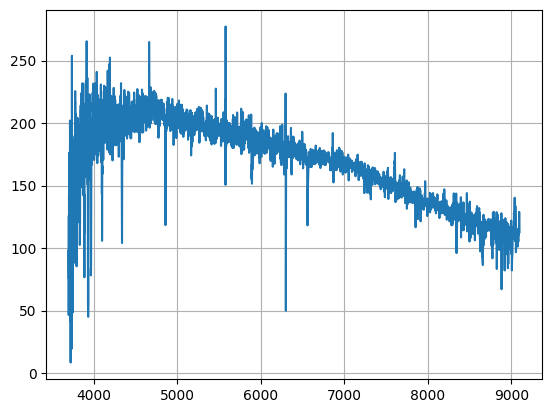

In [100]:
with fits.open(f"{directory_list[0]}/spec-55859-F5902_sp10-085.fits.gz") as star:
    star.info()

    primary_hdu = star[0]
    primary_header = primary_hdu.header
    secondary_hdu = star[1]
    secondary_header = secondary_hdu.header
    secondary_data = secondary_hdu.data

    flux = secondary_data["FLUX"][0]
    wavelength = secondary_data["WAVELENGTH"][0]

plt.plot(wavelength, flux)
plt.grid()


In [89]:
def data_consol(directory_list):
    lamost_data_dict = {}      
    global_idx = 0
    for directory in directory_list:    
        file_list = os.listdir(directory)      # fetch files inside directory
        for file in file_list:
            if "fits.gz" in file and ":Zone" not in file:     # fetch only relevant files
                empty_dict = {}       # create star data dictionary at every iteration
                with fits.open(f"{directory}/{file}") as stellar_data:        # retrieving header data units of the fits file 
                    primary_hdu = stellar_data[0]   
                    primary_header = primary_hdu.header
                    secondary_hdu = stellar_data[1]
                    secondary_header = secondary_hdu.header
                    secondary_data = secondary_hdu.data

                    flux = secondary_data["FLUX"][0]       # datapoint --
                    wavelength_grid = secondary_data["WAVELENGTH"][0] 

                    obs_id = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["obsid"])

                    teff = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["teff"])
                    logg = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["logg"])
                    feh = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["feh"])

                    spectral_class = str(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["subclass"])

                    snru= int(primary_header["SNRU"])
                    snrg= int(primary_header["SNRG"])
                    snrr= int(primary_header["SNRR"])
                    snri= int(primary_header["SNRI"])
                    snrz= int(primary_header["SNRZ"])

                    empty_dict["flux"] = flux
                    empty_dict["wavelength_grid"] = wavelength_grid
                    empty_dict["obsID"] = obs_id
                    empty_dict["teff"] = teff
                    empty_dict["logg"] = logg
                    empty_dict["feh"] = feh
                    empty_dict["Spectral class"] = spectral_class
                    empty_dict["SNRU"] = snru
                    empty_dict["SNRG"] = snrg
                    empty_dict["SNRR"] = snrr
                    empty_dict["SNRI"] = snri
                    empty_dict["SNRZ"] = snrz

            
                lamost_data_dict[global_idx] = empty_dict
                global_idx += 1
    
    return lamost_data_dict
                
lamost_data_dict = data_consol(directory_list = directory_list)


/tmp/ipykernel_1662/4249576130.py:19: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  obs_id = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["obsid"])
/tmp/ipykernel_1662/4249576130.py:21: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  teff = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["teff"])
/tmp/ipykernel_1662/4249576130.py:22: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  logg = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]["logg"])
/tmp/ipykernel_1662/4249576130.py:23: FutureWarning: Calling int on a single element Series is deprecated and will raise a TypeError in the future. Use int(ser.iloc[0]) instead
  feh = int(meta_df[meta_df["obsid"] == primary_header["OBSID"]]

In [99]:
len(lamost_data_dict)

20000